# MCTS Drug Design Testing Notebook

Testing the Monte Carlo Tree Search (MCTS) module for de novo drug design using R-BRICS fragments.
This notebook demonstrates how to:
- Load fragment libraries
- Configure the MCTS engine with custom scoring functions
- Generate molecular candidates
- Analyze and visualize the results

## 1. Import Required Libraries

Import necessary libraries including pandas, NumPy, RDKit, and the MCTSDrugDesign class with make_composite_scorer.

In [7]:
import pandas as pd
from collections import Counter,defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path
import pyarrow as pa
import multiprocessing as mp

from rdkit import Chem
from rdkit.Chem import Draw

from smiles_blocks.mcts import MCTSDrugDesign, make_composite_scorer
from smiles_blocks.rbrics_patterns import RBRICSCompatibilityMap
from smiles_blocks.files import INTERIM_DATA_DIR

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Fragment Library and Compatibility Map

Load the fragment DataFrame from a CSV or pickle file and retrieve the R-BRICS compatibility map for fragment connection rules.

In [2]:
# Define paths
block_library_dir = INTERIM_DATA_DIR / "well_sampled" / "block_library"
df_list = [pd.read_parquet(file) for file in block_library_dir.glob("*.parquet")]
df  = pd.concat(df_list, ignore_index=True)

In [3]:
df_unique =df.drop_duplicates(subset="unique_id")

logger.info(f"Loaded {len(df_unique)} unique fragments")
print(f"Unique Fragment DataFrame shape: {df_unique.shape}")
print(f"Columns: {list(df_unique.columns)}")


# Get compatibility map from R-BRICS patterns
compat = dict(RBRICSCompatibilityMap().patterns)
logger.info(f"Loaded R-BRICS compatibility map with {len(compat)} connection rules")
print(f"\nCompatibility map keys: {list(compat.keys())}")

INFO:__main__:Loaded 119645 unique fragments
INFO:__main__:Loaded R-BRICS compatibility map with 25 connection rules


Unique Fragment DataFrame shape: (119645, 14)
Columns: ['block', 'can_smiles', 'first_connected_can_idx', 'last_connected_can_idx', 'unique_id', 'begin_tag', 'end_tag', 'MolWt', 'nHDonors', 'nHAcceptors', 'nRotatableBonds', 'CrippenlogP', 'TPSA', 'status']

Compatibility map keys: ['L1', 'L30', 'L3', 'L4', 'L5', 'L51', 'L6', 'L7a', 'L8', 'L81', 'L9', 'L10', 'L11', 'L12b', 'L13', 'L14', 'L14b', 'L15', 'L16', 'L16b', 'L17', 'L18', 'L182', 'L20', 'L22']


In [4]:
blocked_smiles_dir = INTERIM_DATA_DIR / "well_sampled" / "blocked_smiles"
df_list = [pd.read_parquet(file) for file in blocked_smiles_dir.glob("*.parquet")]
df_blocked_smiles = pd.concat(df_list, ignore_index=True)

In [5]:
successful_blocking = df_blocked_smiles[df_blocked_smiles["fragmentation_success"]]

In [9]:
def count_block_counts(blocked_smiles: str) -> Counter:
    """Count the frequency of each block in a blocked SMILES string."""
    list_of_blocks = blocked_smiles.split(".")
    return Counter(list_of_blocks)

def get_conditional_block_counts(blocked_smiles: str, block2unique_id : dict[str, str]) -> defaultdict[str, Counter]:
    """Count block frequencies conditioned on fragmentation success."""
    conditional_counts = defaultdict(Counter)

    blocks = blocked_smiles.split(".")

    for i, block in enumerate(blocks):
        unique_id = block2unique_id.get(block, "unknown")
        next_block = blocks[i + 1] if i + 1 < len(blocks) else None

        if next_block:
            next_unique_id = block2unique_id.get(next_block, "unknown")
            conditional_counts[unique_id][next_unique_id] += 1
    return conditional_counts

In [6]:
block2unique_id = {block: unique_id for unique_id, block in zip(df["unique_id"], df["block"])}

In [10]:
conditional_block_counts = defaultdict(Counter)
for blocked_smiles in successful_blocking["smiles_blocked"]:
    counts = get_conditional_block_counts(blocked_smiles, block2unique_id)
    for unique_id, counter in counts.items():
        conditional_block_counts[unique_id].update(counter)

In [11]:
conditional_block_counts_df = pd.DataFrame.from_records(
    (
        {
            "unique_id": unique_id,
            "next_unique_id": next_unique_id,
            "frequency": frequency,
        }
        for unique_id, counter in conditional_block_counts.items()
        for next_unique_id, frequency in counter.items()
    ),
    columns=["unique_id", "next_unique_id", "frequency"],
)

conditional_block_counts_df

,unique_id,next_unique_id,frequency
0,6_c1ccc(C2CCNc3ncnn32)cc1_6,4_Cc1ccccc1_0,1
1,6_c1ccc(C2CCNc3ncnn32)cc1_6,2_c1ccsc1_1,1
2,2_O=CC1CC(=O)Nc2ncnn21_1,0_N_0,3
3,0_N_0,3_Fc1ccccc1_0,1022
4,0_N_0,4_Brc1ccccc1_0,233
...,...,...,...
446667,1_Nc1cc(=O)c2ccccc2o1_2,0_c1ccccc1_3,1
446668,11_Nc1cc(=O)c2ccccc2o1_2,0_C=O_0,2
446669,1_Cc1cccc2c(=O)cc(N)oc12_8,0_c1ccc2c(c1)OCO2_1,1
446670,11_Cc1ccc2c(c1)C(=O)OCC2_10,0_C=O_0,1


In [13]:
conditional_block_counts_df = pd.DataFrame.from_records(
    (
        {
            "unique_id": unique_id,
            "next_unique_id": next_unique_id,
            "frequency": frequency,
        }
        for unique_id, counter in conditional_block_counts.items()
        for next_unique_id, frequency in counter.items()
    ),
    columns=["unique_id", "next_unique_id", "frequency"],
)

conditional_block_counts_df["proba"] = (
    conditional_block_counts_df["frequency"]
    / conditional_block_counts_df.groupby("unique_id")["frequency"].transform("sum")
)

conditional_block_counts_df

,unique_id,next_unique_id,frequency,proba
0,6_c1ccc(C2CCNc3ncnn32)cc1_6,4_Cc1ccccc1_0,1,0.500000
1,6_c1ccc(C2CCNc3ncnn32)cc1_6,2_c1ccsc1_1,1,0.500000
2,2_O=CC1CC(=O)Nc2ncnn21_1,0_N_0,3,1.000000
3,0_N_0,3_Fc1ccccc1_0,1022,0.000736
4,0_N_0,4_Brc1ccccc1_0,233,0.000168
...,...,...,...,...
446667,1_Nc1cc(=O)c2ccccc2o1_2,0_c1ccccc1_3,1,1.000000
446668,11_Nc1cc(=O)c2ccccc2o1_2,0_C=O_0,2,1.000000
446669,1_Cc1cccc2c(=O)cc(N)oc12_8,0_c1ccc2c(c1)OCO2_1,1,1.000000
446670,11_Cc1ccc2c(c1)C(=O)OCC2_10,0_C=O_0,1,1.000000


In [14]:
print(conditional_block_counts_df.head())

                     unique_id  next_unique_id  frequency     proba
0  6_c1ccc(C2CCNc3ncnn32)cc1_6   4_Cc1ccccc1_0          1  0.500000
1  6_c1ccc(C2CCNc3ncnn32)cc1_6     2_c1ccsc1_1          1  0.500000
2     2_O=CC1CC(=O)Nc2ncnn21_1           0_N_0          3  1.000000
3                        0_N_0   3_Fc1ccccc1_0       1022  0.000736
4                        0_N_0  4_Brc1ccccc1_0        233  0.000168


In [ ]:

# Notebook-safe implementation: avoid multiprocessing pool workers trying to
# import a function from __main__.
block_counts_list = [
    count_block_counts(smiles)
    for smiles in successful_blocking["smiles_blocked"].tolist()
]

aggregated_counts = Counter()
for block_count in block_counts_list:
    aggregated_counts.update(block_count)

aggregated_counts

Counter({'N': 1388233,
         'C(=O)': 1060058,
         'C': 673089,
         'O': 388391,
         'C-C': 373183,
         'O-C': 243737,
         'C-C(=O)': 204602,
         'C(=O)-C': 203301,
         'S(=O)(=O)': 141333,
         'N(-C)': 136655,
         'C1-C=C-C(=C-C=1)': 117497,
         'C1=C-C=C(-C=C-1)': 116875,
         'C(-C)': 113348,
         'S': 109006,
         'C1=C-C=C-C=C-1': 98950,
         'C(-C)-C': 97461,
         'C-O': 79731,
         'C#N': 72069,
         'C-C-C': 71624,
         'N1-C-C-N(-C-C-1)': 70965,
         'O(-C)': 64463,
         'C1-C-C-1': 64304,
         'C1-C(=C-C=C-C=1)': 58746,
         'C1-C=C-C=C-C=1': 50850,
         'C1-C=C-C=C(-C=1)': 48455,
         'C1=C-C(=C-C=C-1)': 48170,
         'C-C-C(=O)': 46855,
         'C(=O)-C-C': 42260,
         'C1=C-C=C-C(=C-1)': 38919,
         'C1-C=C(-C=C-C=1)': 38578,
         'C(-C)(-C)': 36449,
         'C-C(-C)': 31514,
         'N(-C-C)': 31290,
         'C(-C)-C(=O)': 30965,
         'C(-C)(-

In [8]:
unique_id_counts = {unique_id : 0 for unique_id in df["unique_id"]}
not_found_count = 0

for block, count in aggregated_counts.items():
    unique_id = block2unique_id.get(block)
    if unique_id is not None:
        unique_id_counts[unique_id] += count
    else:
        not_found_count += 1
        logger.warning(f"Block '{block}' not found in block2unique_id mapping")

In [9]:
not_found_count

0

In [10]:
df_unique["frequency"] = df_unique["unique_id"].map(unique_id_counts)

## 3. Initialize MCTS Drug Designer

Create an MCTSDrugDesign instance with the fragment library, compatibility map, and custom scoring function using make_composite_scorer with specified weights and thresholds.

In [11]:
fragment_table = pa.Table.from_pandas(df_unique)

In [12]:
# Initialize MCTS Drug Designer
mcts = MCTSDrugDesign(
    fragment_table=fragment_table,
    compatibility_map=compat,
    block_count_mu=5.5,
    block_count_sigma=1.41,
    n_iter=40_000,
    min_blocks=3,
    max_blocks=10,
    score_fn = make_composite_scorer()
)

logger.info("MCTS Drug Designer initialized")

INFO:__main__:MCTS Drug Designer initialized


## 4. Run MCTS to Generate Molecules

Execute the MCTS search with n_molecules=100 to generate candidate drug molecules and collect results including SMILES, scores, block counts, and fragment IDs.

In [13]:
print("This may take a few minutes...\n")
results = mcts.run(n_runs=300, score_threshold=1)


This may take a few minutes...



INFO:smiles_blocks.mcts:442146 unique molecules above threshold 1.00 from 300 runs.



=== MCTS Timing Profile ===
---------------------------------------------------------
Operation         Total(s)    Calls    Mean(ms)    Share%
---------------------------------------------------------
expand            16021.967  12000000       1.335     63.6%
score             4951.967  12000000       0.413     19.7%
expand_pop        2592.789  12000000       0.216     10.3%
prior_compute      986.190  12000000       0.082      3.9%
simulate           237.100  12000000       0.020      0.9%
library_query      215.065  31911160       0.007      0.9%
select             158.234  12000000       0.013      0.6%
expand_node         11.287  12000000       0.001      0.0%
expand_clone         9.360  12000000       0.001      0.0%
backprop             4.934  12000000       0.000      0.0%
expand_pool_init     0.042      300       0.140      0.0%
---------------------------------------------------------
TOTAL             25188.936
---------------------------------------------------------


## 5. Analyze Results

Convert results to a pandas DataFrame and compute summary statistics including score distribution, block count distribution, and identify top-scoring candidates.

In [17]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Summary statistics
print("=== RESULTS SUMMARY ===\n")
print(f"Total molecules generated: {len(results_df)}")
print(f"\nScore Statistics:")
print(results_df['score'].describe())
print(f"\nBlock Count Statistics:")
print(results_df['n_blocks'].describe())

# Top scoring molecules
top_n = 10
print(f"\n=== TOP {top_n} MOLECULES ===")
top_df = results_df.nlargest(top_n, 'score')[['smiles', 'score', 'n_blocks']]
print(top_df.to_string(index=False))

# Save results
output_file = Path("../data/processed") / "mcts_results.csv"
output_file.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_file, index=False)
logger.info(f"Results saved to {output_file}")
print(f"\nResults saved to: {output_file}")

=== RESULTS SUMMARY ===

Total molecules generated: 442146

Score Statistics:
count    442146.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: score, dtype: float64

Block Count Statistics:
count    442146.000000
mean          3.473104
std           0.648538
min           3.000000
25%           3.000000
50%           3.000000
75%           4.000000
max           7.000000
Name: n_blocks, dtype: float64

=== TOP 10 MOLECULES ===
                                                                                  smiles  score  n_blocks
                      O(-C)C1=C-C(-C-O)=C-C(-Cl)=C-1C1=C-C=C(-O-C)-C(=C-1)C1=C-C=N-C=C-1    1.0         4
                               O=C(-C)C1=C-C(=N-O-1)C1-C=C(-N=C-C=1)C1=N-C(=C(-O-1)-C)-C    1.0         4
                           C(-F)(-F)(-F)-CNC1=C-C=C(-C=C-1)C1-C=C2-C(-N-C(-N-2)=O)=C-C=1    1.0         4
                                                      C(-C)N

INFO:__main__:Results saved to ../data/processed/mcts_results.csv



Results saved to: ../data/processed/mcts_results.csv


## 6. Visualize Results

Display molecular structures of top-scoring molecules using RDKit and create plots showing score vs. block count and other relevant metrics.

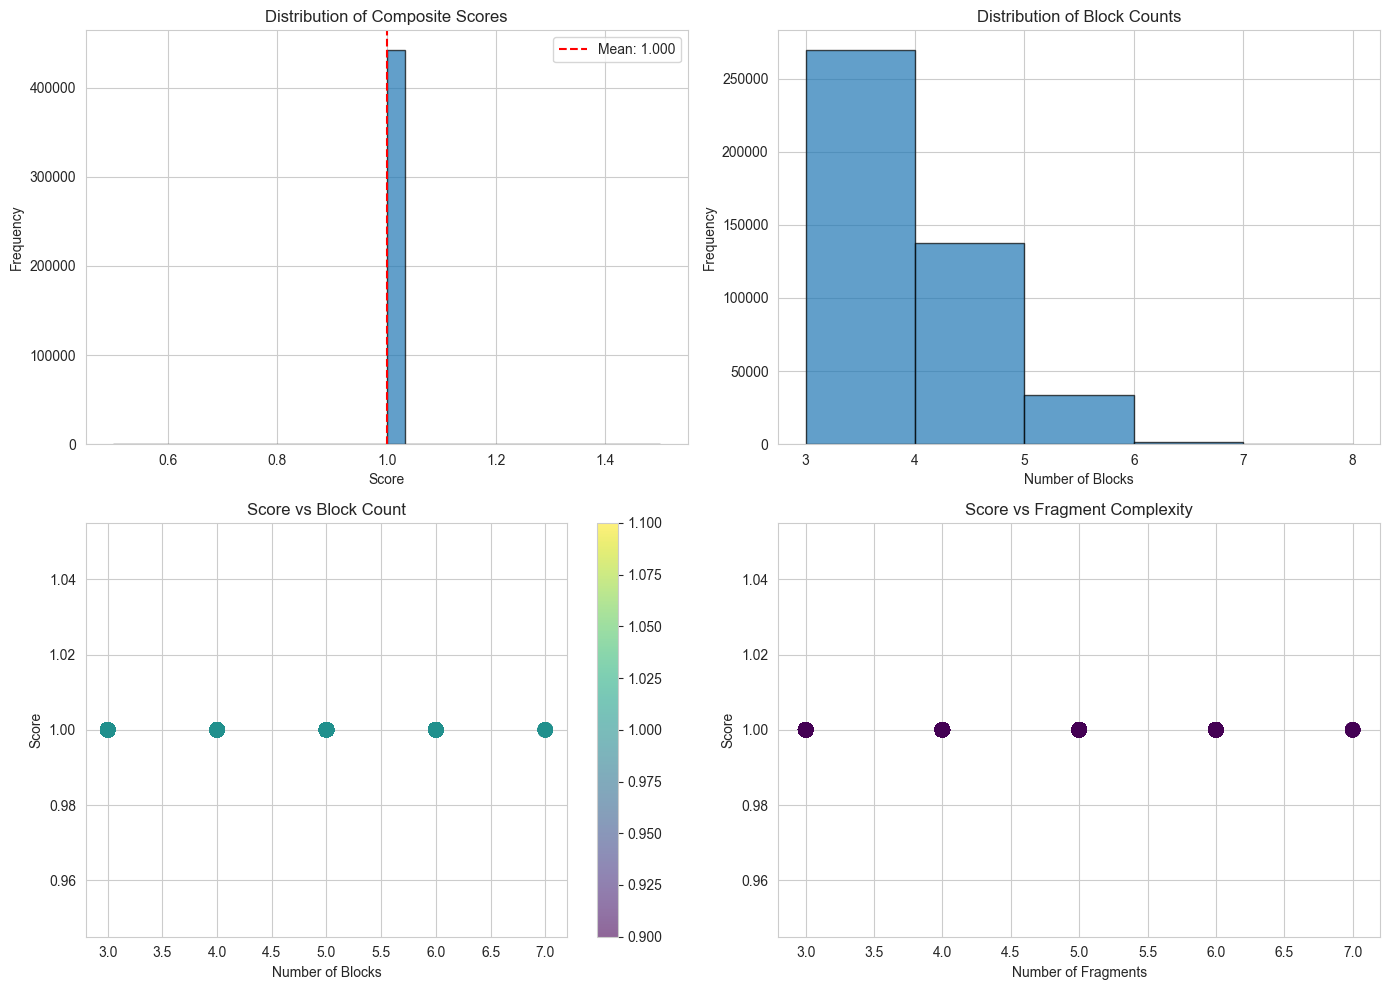

Visualization complete!


In [18]:
# Plot 1: Score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score histogram
axes[0, 0].hist(results_df['score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].axvline(results_df['score'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['score'].mean():.3f}")
axes[0, 0].legend()

# Block count distribution
axes[0, 1].hist(results_df['n_blocks'], bins=range(int(results_df['n_blocks'].min()), int(results_df['n_blocks'].max()) + 2), edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Blocks')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Block Counts')

# Score vs block count scatter plot
scatter = axes[1, 0].scatter(results_df['n_blocks'], results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 0].set_xlabel('Number of Blocks')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Score vs Block Count')
plt.colorbar(scatter, ax=axes[1, 0])

# Score vs fragment count (proxy for complexity)
axes[1, 1].scatter(results_df['fragment_ids'].apply(len), results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 1].set_xlabel('Number of Fragments')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Score vs Fragment Complexity')

plt.tight_layout()
plt.show()

print("Visualization complete!")

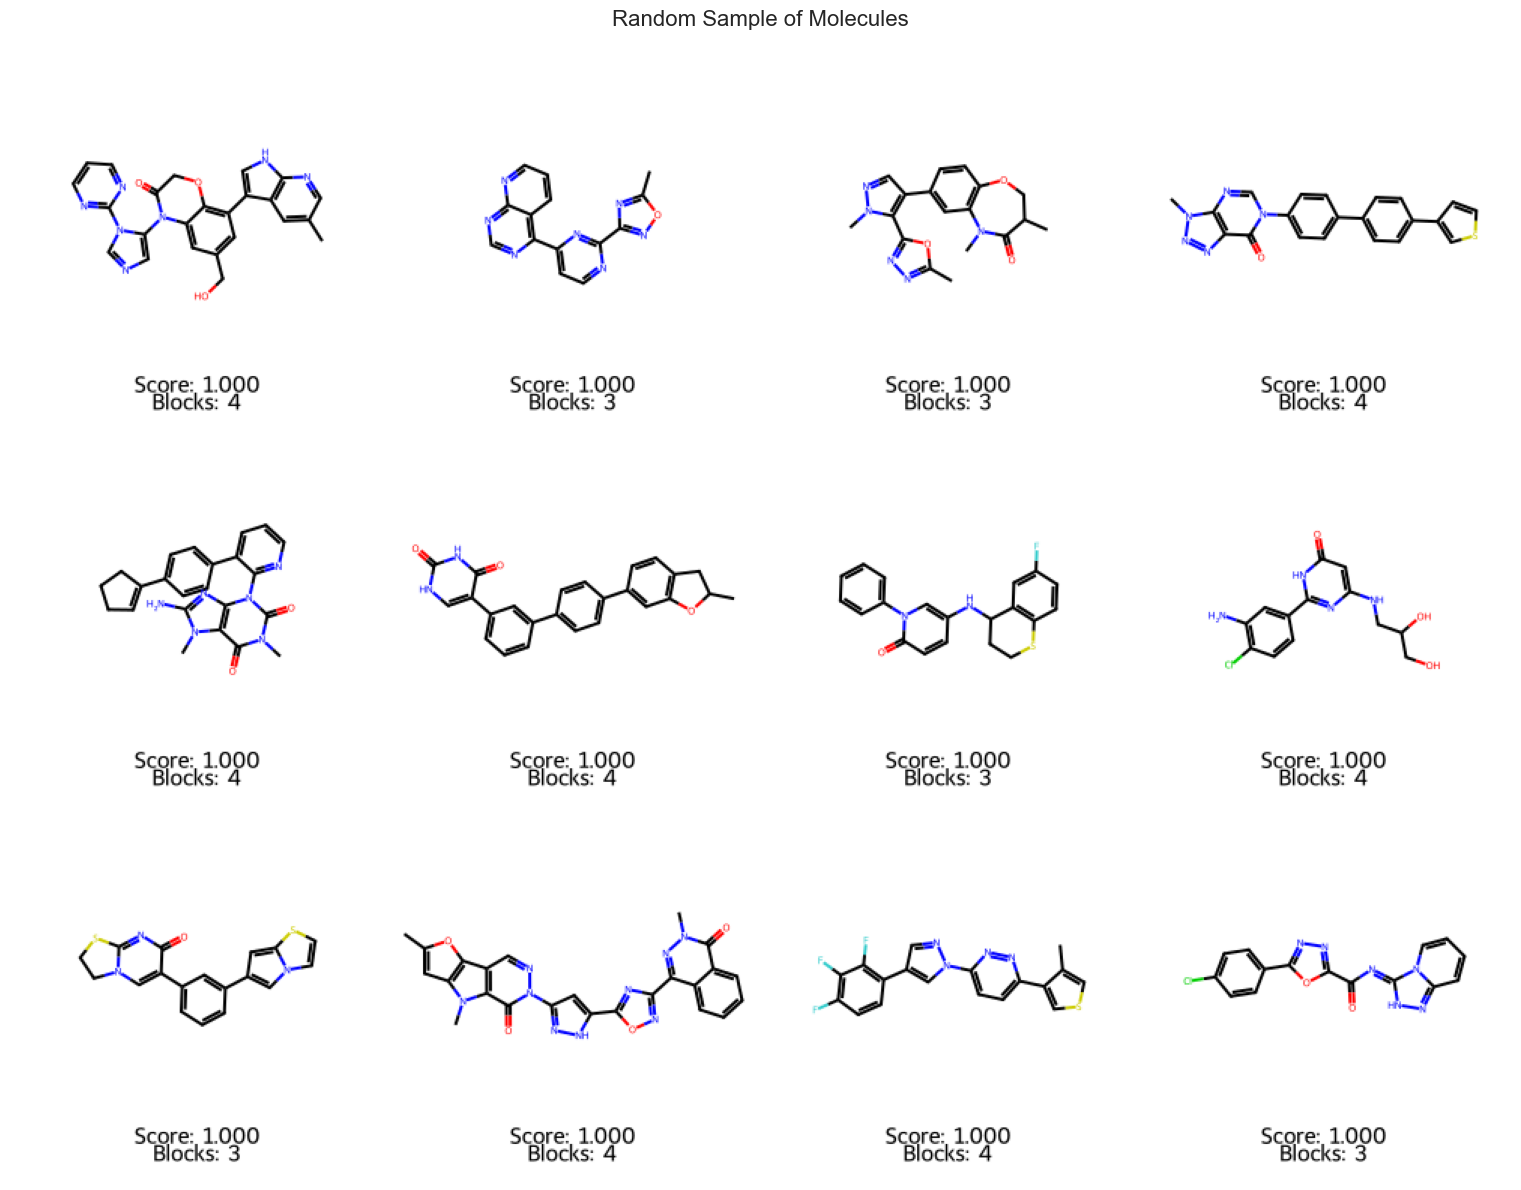

In [22]:
# Display 12 random molecule structures (or fewer if not enough results)
num_display = min(len(results_df), 12)
if num_display == 0:
    print("No molecules to display")
else:
    top_mols = results_df.sample(n=num_display)
    mols = []
    legends = []

    for idx, row in top_mols.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is not None:
            mols.append(mol)
            legends.append(f"Score: {row['score']:.3f}\nBlocks: {row['n_blocks']}")

    if mols:
        img = Draw.MolsToGridImage(
            mols,
            molsPerRow=4,
            subImgSize=(250, 250),
            legends=legends,
            returnPNG=False
        )
        plt.figure(figsize=(16, 12))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Random Sample of Molecules', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: Could not generate molecule structures from SMILES strings")

In [27]:

def smi2cansmiles(smi: str) -> str | None:
    """Convert a SMILES string to its canonical form."""
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        logger.warning(f"Invalid SMILES string: {smi}")
        return None

results_df['canonical_smiles'] = results_df['smiles'].apply(smi2cansmiles)

In [28]:
len(results_df['canonical_smiles'].dropna().unique())/ len(results_df)

0.9518032505100126

In [30]:
print(results_df.head())

                                              smiles  score  n_blocks  \
0  O(-C)C1=C-C(-C-O)=C-C(-Cl)=C-1C1=C-C=C(-O-C)-C...    1.0         4   
1  O=C(-C)C1=C-C(=N-O-1)C1-C=C(-N=C-C=1)C1=N-C(=C...    1.0         4   
2  C(-F)(-F)(-F)-CNC1=C-C=C(-C=C-1)C1-C=C2-C(-N-C...    1.0         4   
3                 C(-C)NC1=N-O-C(=N-1)C1=C-C=N-C=C-1    1.0         4   
4  N1(-C2-C(=C-C=C-C=2)-N-C-1=O)C1=N-C=C-C=C-1C1=...    1.0         4   

                                        fragment_ids  \
0  [1_CO_1, 4_OCc1cccc(Cl)c1_5, 5_COc1ccccc1_7, 0...   
1  [2_CC=O_1, 4_c1cnoc1_1, 0_c1ccncc1_2, 3_Cc1nco...   
2  [1_CC(F)(F)F_0, 0_N_0, 0_c1ccccc1_3, 5_O=c1[nH...   
3         [0_CC_0, 0_N_0, 0_c1ncon1_2, 0_c1ccncc1_5]   
4  [9_O=c1[nH]c2ccccc2[nH]1_9, 4_c1ccncc1_5, 0_c1...   

                                    canonical_smiles  
0           COc1ccc(-c2c(Cl)cc(CO)cc2OC)cc1-c1ccncc1  
1           CC(=O)c1cc(-c2ccnc(-c3nc(C)c(C)o3)c2)no1  
2       O=c1[nH]c2ccc(-c3ccc(NCC(F)(F)F)cc3)cc2[nH]1  
3   

In [31]:
moses_df  = pd.read_csv("../data/external/moses_dataset.csv")

In [33]:
print(moses_df.head())

                                   SMILES  SPLIT
0  CCCS(=O)c1ccc2[nH]c(=NC(=O)OC)[nH]c2c1  train
1    CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1  train
2  CC1C2CCC(C2)C1CN(CCO)C(=O)c1ccc(Cl)cc1   test
3     Cc1c(Cl)cccc1Nc1ncccc1C(=O)OCC(O)CO  train
4        Cn1cnc2c1c(=O)n(CC(O)CO)c(=O)n2C  train


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED
from rdkit.Contrib.SA_Score import sascorer

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

In [ ]:
PROPERTIES = [
    ("mol_weight", "Molecular Weight (Da)",               None,  None),
    ("logp",       "LogP",                                None,  None),
    ("hbd",        "H-Bond Donors",                       None,  None),
    ("hba",        "H-Bond Acceptors",                    None,  None),
    ("rot_bonds",  "Rotatable Bonds",                     None,  None),
    ("tpsa",       "Topological Polar Surface Area (Å²)", None,  None),
    ("qed",        "QED",                                 0.0,   1.0),
    ("sa_score",   "SA Score",                            1.0,  10.0),
]


def compute_props(smiles_series, n_workers=None, chunk_size=1000):
    """Return dict of property_key -> np.ndarray for all valid SMILES.

    This implementation parallelizes work by splitting the SMILES list into
    chunks and using ``multiprocessing.Pool`` to compute descriptors per chunk.
    It relies on the module ``smiles_blocks.parallel_utils`` so worker processes
    can import the helper function safely from a module (avoid pickling
    notebook-local functions).
    """
    import numpy as np
    import multiprocessing as mp
    from smiles_blocks.parallel_utils import compute_props_chunk, merge_chunk_results

    smiles_list = [s for s in smiles_series.dropna()]
    if not smiles_list:
        return {k: np.array([]) for k, *_ in PROPERTIES}

    n_workers = n_workers or max(1, mp.cpu_count() - 1)
    # create chunks
    chunks = [smiles_list[i:i + chunk_size] for i in range(0, len(smiles_list), chunk_size)]

    if n_workers <= 1 or len(chunks) == 1:
        results = [compute_props_chunk(chunk) for chunk in chunks]
    else:
        with mp.Pool(processes=min(n_workers, len(chunks))) as pool:
            results = pool.map(compute_props_chunk, chunks)

    merged = merge_chunk_results(results)
    return {k: np.array(v) for k, v in merged.items()}


In [37]:
# Adjust column names if yours differ
moses_smiles  = moses_df["SMILES"]          # or "smiles"
sample_smiles = results_df["canonical_smiles"]  # or "smiles"

moses_props  = compute_props(moses_smiles)
sample_props = compute_props(sample_smiles)

print(f"MOSES   valid: {len(moses_props['mol_weight']):,}")
print(f"Samples valid: {len(sample_props['mol_weight']):,}")

MOSES   valid: 1,936,962
Samples valid: 442,146


/var/folders/3y/7l0sjs0s3p5980563tk_fm3h0000gp/T/ipykernel_8720/3004226886.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


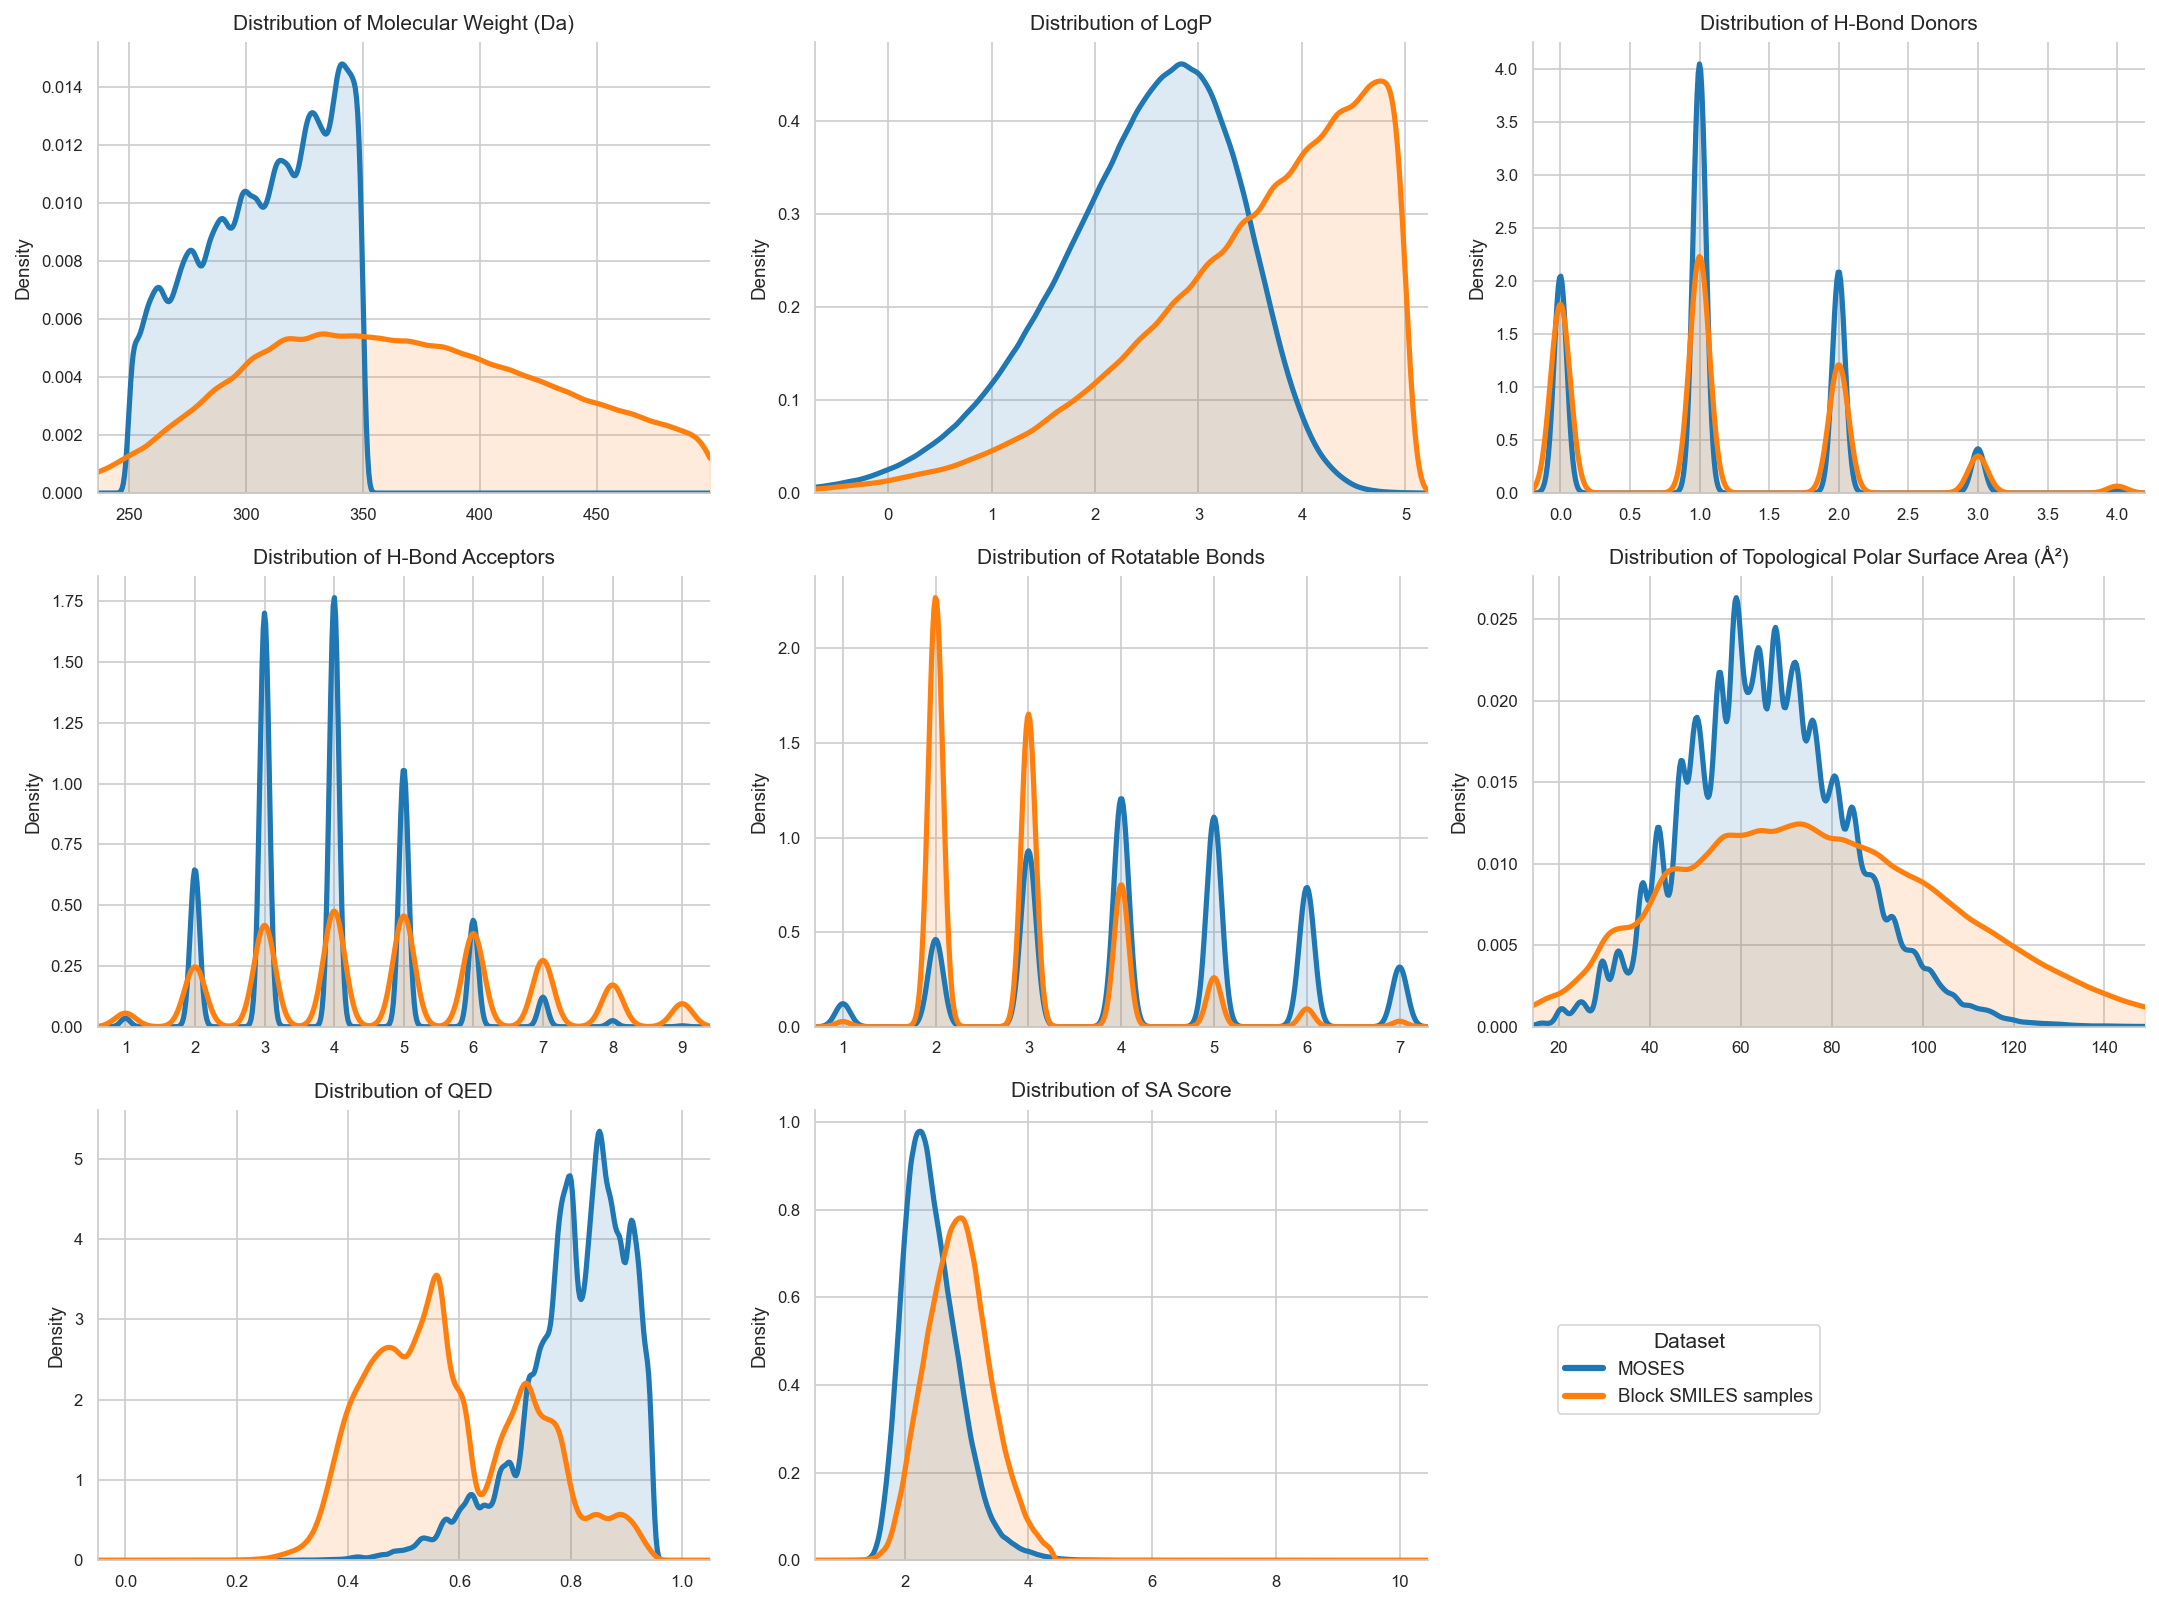

In [38]:
MOSES_COLOR  = "#1f77b4"
SAMPLE_COLOR = "#ff7f0e"
KDE_PTS      = 500

def _kde(ax, vals, color, lo, hi):
    vals = vals[np.isfinite(vals)]
    if len(vals) < 10:
        return
    pad = (hi - lo) * 0.05
    x   = np.linspace(lo - pad, hi + pad, KDE_PTS)
    y   = gaussian_kde(vals, bw_method="scott")(x)
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.fill_between(x, y, alpha=0.15, color=color)

fig, axes = plt.subplots(3, 3, figsize=(14.5, 10.8))
fig.patch.set_facecolor("white")

for idx, (key, title, x_min, x_max) in enumerate(PROPERTIES):
    ax = axes[idx // 3][idx % 3]
    ax.set_facecolor("white")

    m = moses_props[key]
    s = sample_props[key]
    all_v = np.concatenate([m, s])
    all_v = all_v[np.isfinite(all_v)]

    lo = x_min if x_min is not None else np.percentile(all_v, 0.5)
    hi = x_max if x_max is not None else np.percentile(all_v, 99.5)

    _kde(ax, m, MOSES_COLOR,  lo, hi)
    _kde(ax, s, SAMPLE_COLOR, lo, hi)

    ax.set_title(f"Distribution of {title}", fontsize=10, pad=6)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(lo - (hi - lo) * 0.05, hi + (hi - lo) * 0.05)
    ax.set_ylim(bottom=0)

# Legend in cell 9
axes[2][2].set_visible(False)
leg_ax = fig.add_axes([0.68, 0.06, 0.20, 0.18])
leg_ax.set_axis_off()
handles = [
    Line2D([0], [0], color=MOSES_COLOR,  linewidth=3, label="MOSES"),
    Line2D([0], [0], color=SAMPLE_COLOR, linewidth=3, label="Block SMILES samples"),
]
leg = leg_ax.legend(handles=handles, title="Dataset",
                    title_fontsize=10, fontsize=9, loc="center",
                    frameon=True, framealpha=0.8, edgecolor="#cccccc")
leg.get_frame().set_linewidth(0.8)

fig.tight_layout()
plt.show()